# Housekeeping

## Imports

In [1]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from itertools import product
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
from scipy.stats import skew, kurtosis, spearmanr, kstest, shapiro
from typing import Callable, List, Dict

warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve().parent
DATASETS = HERE.parent/'datasets'

# from google.colab import drive
# %load_ext google.colab.data_table
# drive.mount('/content/drive')

In [2]:
from matplotlib import rcParams
sns.set_theme(style="ticks")

# Set global font sizes
rcParams.update({
    'axes.titlesize': 18,       # Title font size
    'axes.labelsize': 16,       # X and Y label font size
    'axes.labelweight': 'bold',
    'xtick.labelsize': 14,      # X tick label font size
    'ytick.labelsize': 14,      # Y tick label font size
    'legend.fontsize': 14,      # Legend font size
    'font.size': 14             # Default font size
})


## Load data

In [4]:
data_folder = DATASETS/ "processed"
substrate_data_clean_hierarch: pd.DataFrame = pd.read_csv(data_folder/'substrate_hierarchically_averaged_clean_data.csv')
scan_data_clean: pd.DataFrame = pd.read_csv(data_folder/'cleaned_scan_data.csv')

# Physics-based modeling

## Group by carbon number

In [5]:
physics_data_clean = scan_data_clean.groupby(['carbon number', 'electrode']).agg(
      **{

        **{f"{stat_name} {scale_name} @ {v_name} V": (f"scan mean {scale_name} @ {v_name} V", stats_funcs[stat_name]) for v_name, stat_name, scale_name in product(voltages, stats_funcs.keys(), scales)
        },

        # More stats features
        "sample size": ("scan ID", "size"),
    }
  ).reset_index()

NameError: name 'voltages' is not defined

In [6]:
len(physics_data_clean)

NameError: name 'physics_data_clean' is not defined

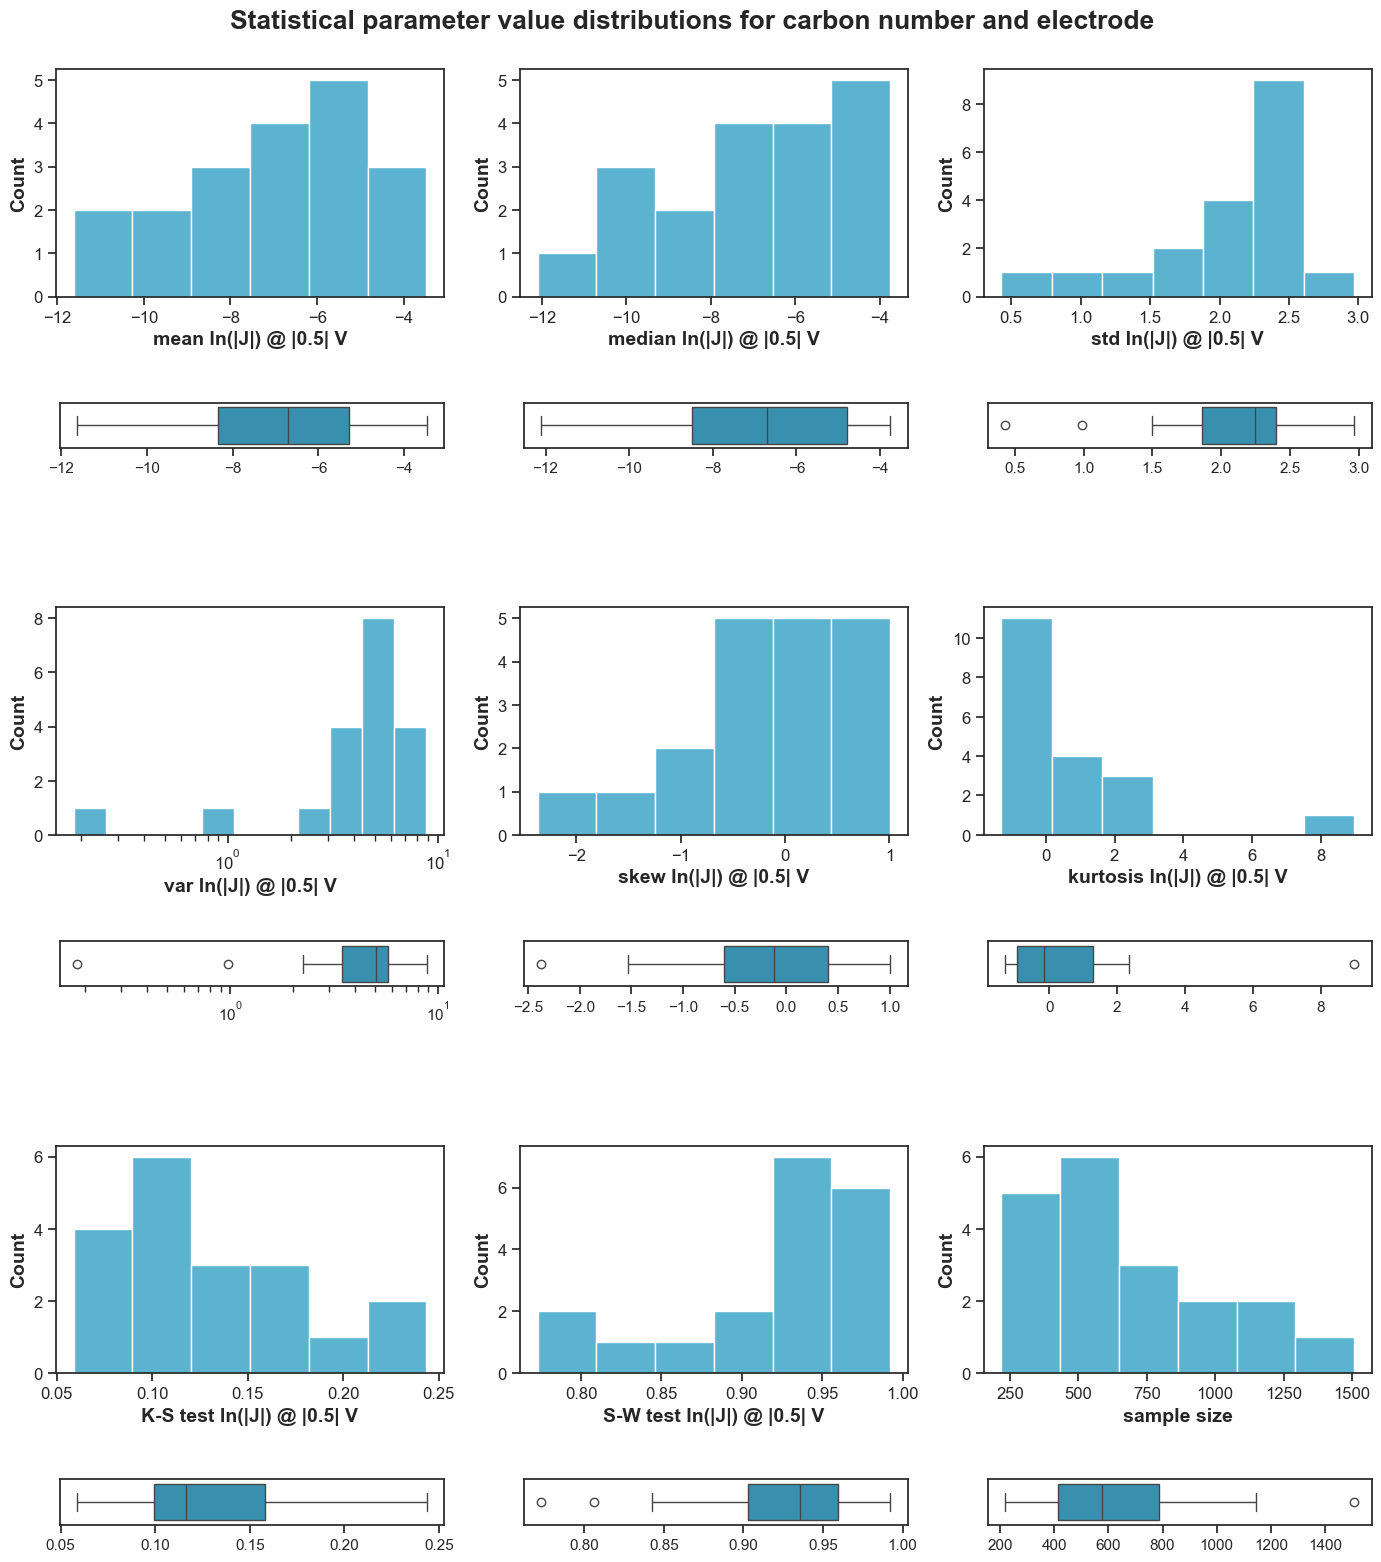

In [155]:
distribution_plot(df=physics_data_clean, parameters=statistical_parameters, columns_per_row=3,
                  log_cutoff=10, figsize=(14,17),title = "Statistical parameter value distributions for carbon number and electrode")

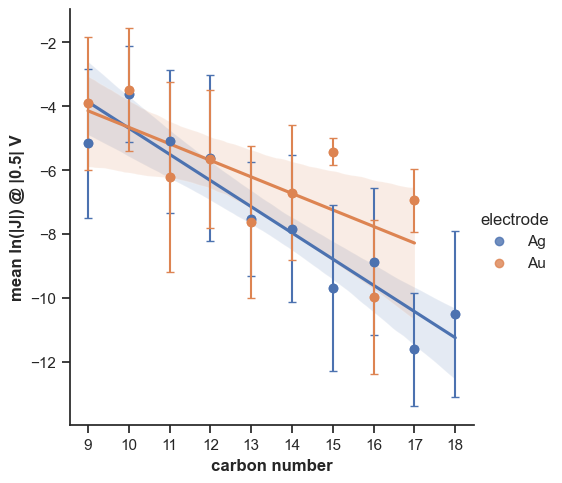

In [156]:
lm = sns.lmplot(data=physics_data_clean, x="carbon number", y="mean ln(|J|) @ |0.5| V", hue="electrode")
lm.set(xticks=list(range(9, 19)))

hue_order = physics_data_clean["electrode"].unique()
palette = sns.color_palette(n_colors=len(hue_order))

for hue_value, color in zip(hue_order, palette):
    subset = physics_data_clean[physics_data_clean["electrode"] == hue_value]
    lm.ax.errorbar(subset["carbon number"], subset["mean ln(|J|) @ |0.5| V"], yerr=subset["std ln(|J|) @ |0.5| V"],
                fmt='o', ecolor=color, capsize=3, label=hue_value)

## Visualizations

#### Split by electrode

<Axes: xlabel='carbon number', ylabel='scan mean |J| @ |0.5| V'>

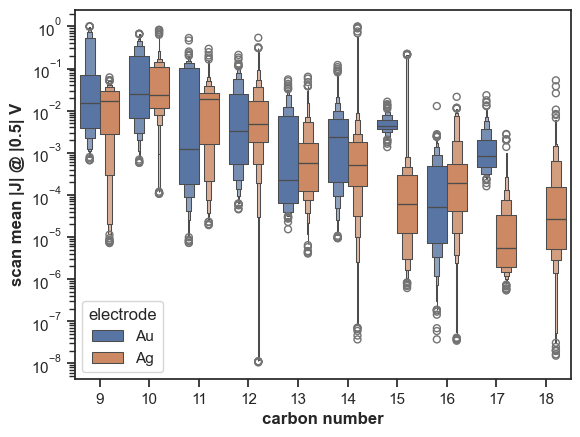

In [157]:
sns.boxenplot(data=scan_data_clean, x="carbon number", y="scan mean |J| @ |0.5| V", hue="electrode", log_scale=True)

<Axes: xlabel='carbon number', ylabel='scan mean ln(|J|) @ |0.5| V'>

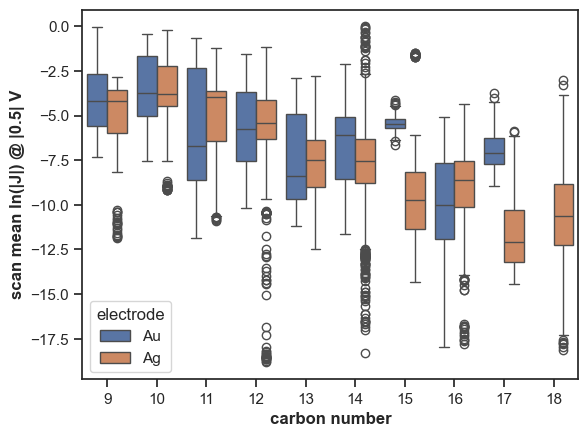

In [158]:
sns.boxplot(data=scan_data_clean, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", hue="electrode")

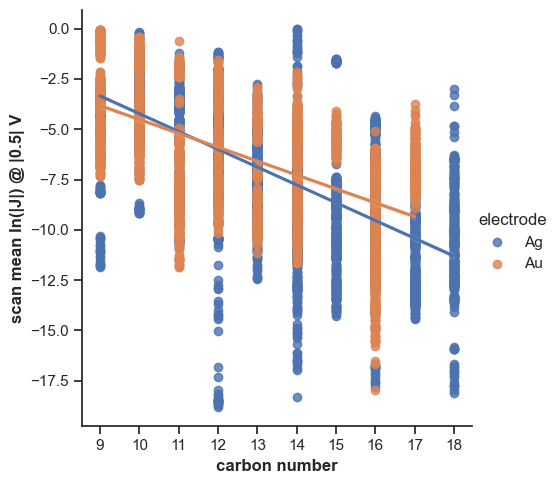

In [159]:
lm = sns.lmplot(data=scan_data_clean, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", hue="electrode")
lm.set(xticks=list(range(9, 19)))

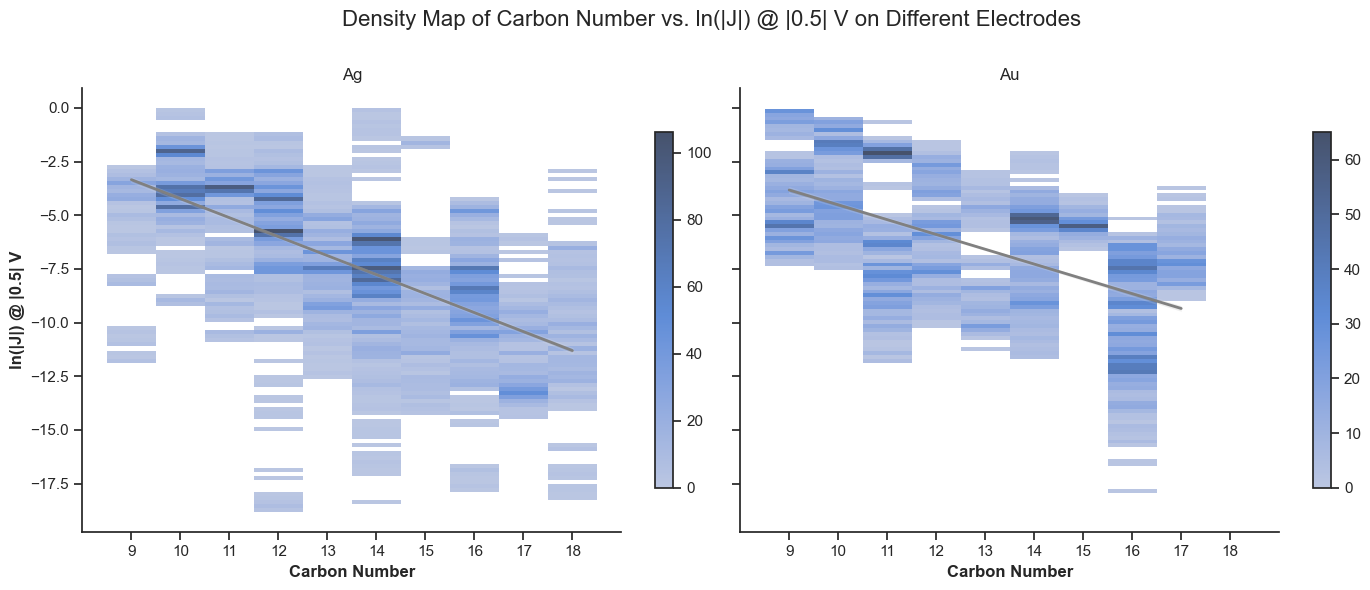

In [160]:
# Create a FacetGrid with shared y-axis
g = sns.FacetGrid(scan_data_clean, col="electrode", sharey=True,
                  height=6, aspect=1.2,
                  )

# Map the histplot to the FacetGrid
g.map_dataframe(sns.histplot, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", bins=100, discrete=(True, False), cbar=True,
                cbar_kws={"shrink": 0.8})

# Overlay a regression plot for each facet
g.map_dataframe(sns.regplot, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", scatter=False, color="grey", line_kws={"linewidth": 2})

# Set axis labels and titles
g.set_axis_labels("Carbon Number", "ln(|J|) @ |0.5| V")
g.set_titles(col_template="{col_name}")
g.set(xticks=list(range(9, 19)))
# Adjust layout for better appearance
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Density Map of Carbon Number vs. ln(|J|) @ |0.5| V on Different Electrodes", fontsize=16)

plt.show()

#### Split by location

<Axes: xlabel='carbon number', ylabel='scan mean ln(|J|) @ |0.5| V'>

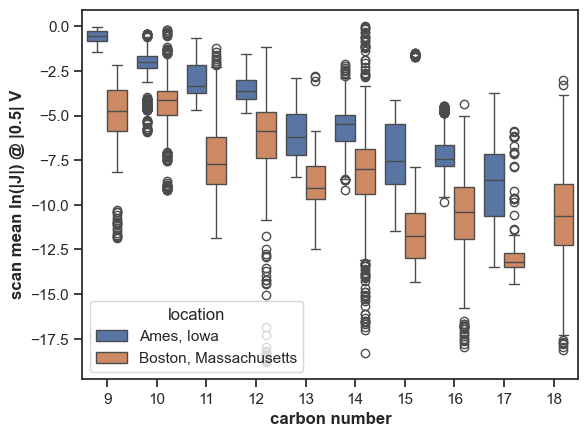

In [161]:
sns.boxplot(data=scan_data_clean, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", hue="location")

<Axes: xlabel='carbon number', ylabel='scan mean |J| @ |0.5| V'>

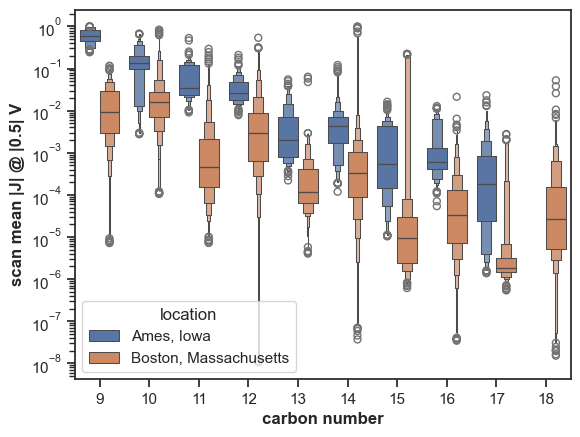

In [162]:
sns.boxenplot(data=scan_data_clean, x="carbon number", y="scan mean |J| @ |0.5| V", hue="location", log_scale=True)

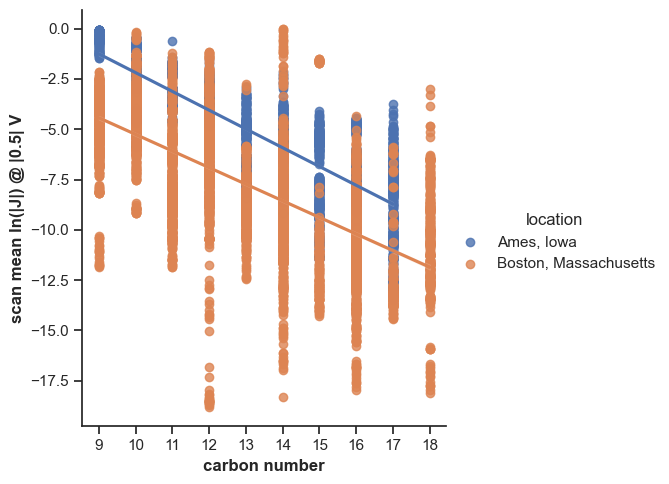

In [163]:
lm = sns.lmplot(data=scan_data_clean, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", hue="location")
lm.set(xticks=list(range(9, 19)))

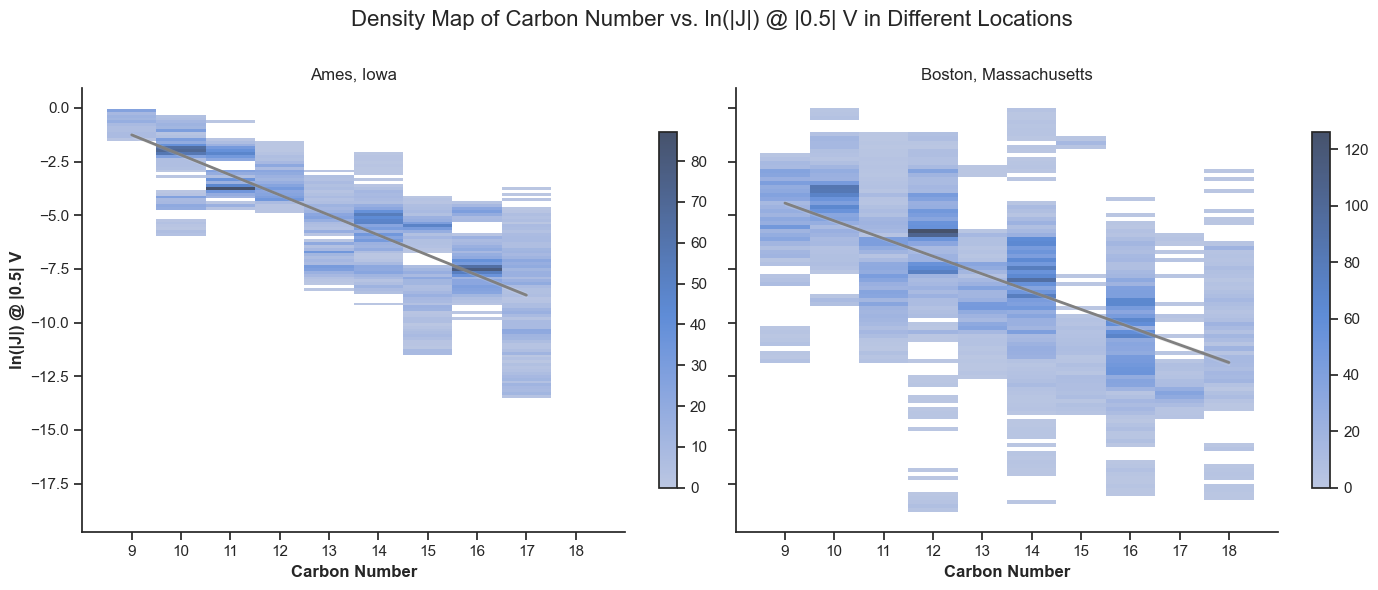

In [164]:
# Create a FacetGrid with shared y-axis
g = sns.FacetGrid(scan_data_clean, col="location", sharey=True,
                  height=6, aspect=1.2,
                  )

# Map the histplot to the FacetGrid
g.map_dataframe(sns.histplot, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", bins=100, discrete=(True, False), cbar=True,
                cbar_kws={"shrink": 0.8})

# Overlay a regression plot for each facet
g.map_dataframe(sns.regplot, x="carbon number", y="scan mean ln(|J|) @ |0.5| V", scatter=False, color="grey", line_kws={"linewidth": 2})

# Set axis labels and titles
g.set_axis_labels("Carbon Number", "ln(|J|) @ |0.5| V")
g.set_titles(col_template="{col_name}")
g.set(xticks=list(range(9, 19)))
# Adjust layout for better appearance
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Density Map of Carbon Number vs. ln(|J|) @ |0.5| V in Different Locations", fontsize=16)

plt.show()

#### Aggregated data

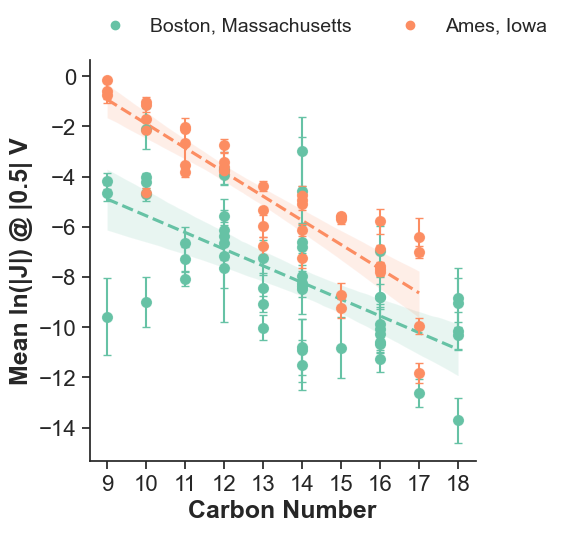

In [7]:
import seaborn as sns
from matplotlib.lines import Line2D

hue_order = substrate_data_clean_hierarch["location"].unique()
palette = sns.color_palette("Set2", n_colors=len(hue_order))
palette_dict = dict(zip(hue_order, palette))

lm = sns.lmplot(
    data=substrate_data_clean_hierarch,
    x="carbon number",
    y="mean ln(|J|) @ |0.5| V",
    hue="location",
    palette=palette_dict,
    scatter_kws={"s": 50},
    legend=False,
    line_kws={"linestyle": "--"}
)

lm.set(xticks=list(range(9, 19)))

for hue_value in hue_order:
    color = palette_dict[hue_value]
    subset = substrate_data_clean_hierarch[
        substrate_data_clean_hierarch["location"] == hue_value
    ]
    lm.ax.errorbar(
        subset["carbon number"],
        subset["mean ln(|J|) @ |0.5| V"],
        yerr=subset["SEM ln(|J|) @ |0.5| V"],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=3
    )

# Increase axis label sizes
lm.set_xlabels("Carbon Number", fontsize=18)
lm.set_ylabels("Mean ln(|J|) @ |0.5| V", fontsize=18)

# Increase tick label sizes
lm.ax.tick_params(axis='x', labelsize=16)
lm.ax.tick_params(axis='y', labelsize=16)

# Custom legend
custom_handles = [
    Line2D([0], [0], marker='o', color=color, linestyle='', label=label)
    for label, color in palette_dict.items()
]

lm.ax.legend(
    handles=custom_handles,
    loc='upper center',
    bbox_to_anchor=(0.6, 1.15),
    ncol=2,
    frameon=False
)


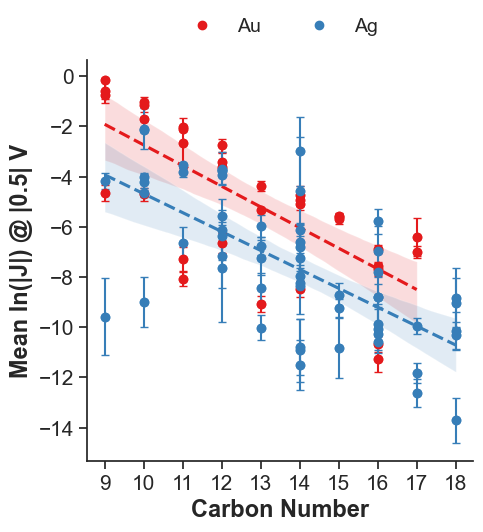

In [8]:

palette = sns.color_palette("Set1")
hue_order = substrate_data_clean_hierarch["electrode"].unique()

lm = sns.lmplot(
    data=substrate_data_clean_hierarch,
    x="carbon number",
    y="mean ln(|J|) @ |0.5| V",
    hue="electrode",
    palette=palette,
    legend=False,
    line_kws={"linestyle": "--"}
)

lm.set(xticks=list(range(9, 19)))

for hue_value, color in zip(hue_order, palette):
    subset = substrate_data_clean_hierarch[
        substrate_data_clean_hierarch["electrode"] == hue_value
    ]
    lm.ax.errorbar(
        subset["carbon number"],
        subset["mean ln(|J|) @ |0.5| V"],
        yerr=subset["SEM ln(|J|) @ |0.5| V"],
        fmt='o',
        color=color,
        ecolor=color,
        capsize=3
    )

# Set bigger axis labels
lm.set_xlabels("Carbon Number", fontsize=17)
lm.set_ylabels("Mean ln(|J|) @ |0.5| V", fontsize=17)

# Increase tick sizes
lm.ax.tick_params(axis='x', labelsize=15)
lm.ax.tick_params(axis='y', labelsize=15)

# Custom legend
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], marker='o', color=color, linestyle='', label=label)
    for label, color in zip(hue_order, palette)
]

lm.ax.legend(
    handles=custom_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False
)

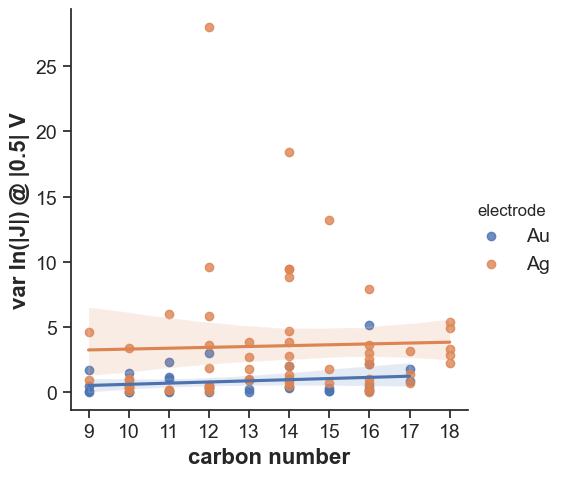

In [9]:
lm = sns.lmplot(data=substrate_data_clean_hierarch, x="carbon number", y="var ln(|J|) @ |0.5| V", hue="electrode")
lm.set(xticks=list(range(9, 19)))

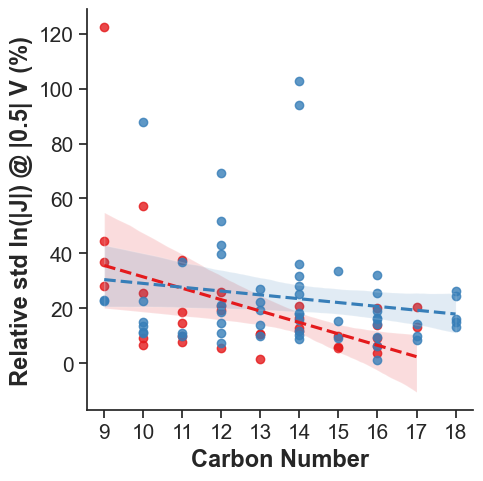

In [10]:
substrate_data_clean_hierarch["relative std ln(|J|) @ |0.5| V (%)"] = (
    abs(
        substrate_data_clean_hierarch["std ln(|J|) @ |0.5| V"] /
        substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"]
    ) * 100
)

lm = sns.lmplot(
    data=substrate_data_clean_hierarch,
    x="carbon number",
    y="relative std ln(|J|) @ |0.5| V (%)",
    hue="electrode",
    palette="Set1",
    legend=False,
    line_kws={"linestyle": "--"}
)

lm.set(xticks=list(range(9, 19)))

# Increase axis label sizes
lm.set_xlabels("Carbon Number", fontsize=17)
lm.set_ylabels("Relative std ln(|J|) @ |0.5| V (%)", fontsize=17)

# Increase tick label sizes
lm.ax.tick_params(axis='x', labelsize=15)
lm.ax.tick_params(axis='y', labelsize=15)


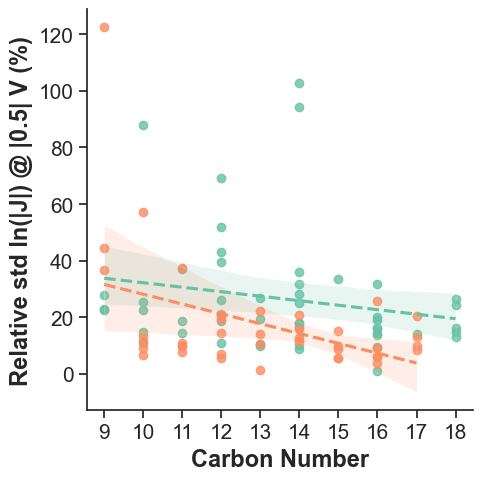

In [11]:
substrate_data_clean_hierarch["relative std ln(|J|) @ |0.5| V (%)"] = (
    abs(
        substrate_data_clean_hierarch["std ln(|J|) @ |0.5| V"] /
        substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"]
    ) * 100
)

lm = sns.lmplot(
    data=substrate_data_clean_hierarch,
    x="carbon number",
    y="relative std ln(|J|) @ |0.5| V (%)",
    hue="location",
    palette="Set2",
    legend=False,
    line_kws={"linestyle": "--"}
)

lm.set(xticks=list(range(9, 19)))

# Increase axis label sizes
lm.set_xlabels("Carbon Number", fontsize=17)
lm.set_ylabels("Relative std ln(|J|) @ |0.5| V (%)", fontsize=17)

# Increase tick label sizes
lm.ax.tick_params(axis='x', labelsize=15)
lm.ax.tick_params(axis='y', labelsize=15)

In [12]:
substrate_data_clean_hierarch["location"]

0     Boston, Massachusetts
1                Ames, Iowa
2                Ames, Iowa
3                Ames, Iowa
4                Ames, Iowa
              ...          
86    Boston, Massachusetts
87               Ames, Iowa
88               Ames, Iowa
89               Ames, Iowa
90               Ames, Iowa
Name: location, Length: 91, dtype: object

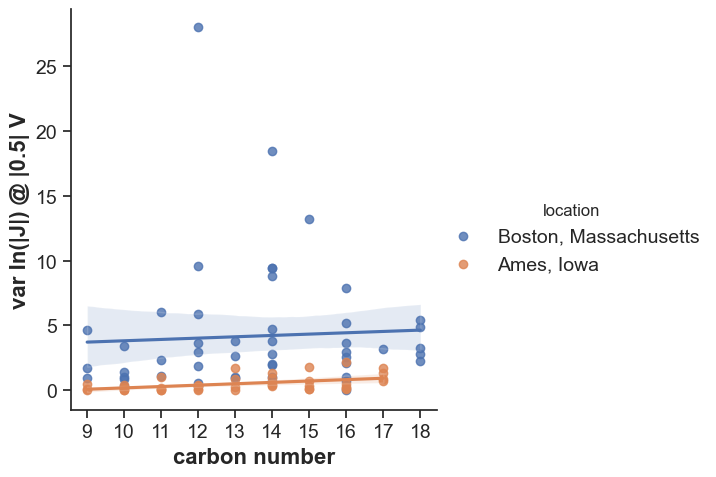

In [13]:
lm = sns.lmplot(data=substrate_data_clean_hierarch, x="carbon number", y="var ln(|J|) @ |0.5| V", hue="location")
lm.set(xticks=list(range(9, 19)))

## Regression

#### Regression tools

In [14]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.utils.validation import check_X_y, check_array


def fit_model(model, x, y, heterosked=False, sample_weights=None):
  if heterosked and sample_weights is None:
    raise ValueError("Sample weights must be provided when using heteroskedastic errors.")

  if sample_weights is None:
    sample_weights = np.ones_like(y)  # Homoskedastic is sample_weights is None. Otherwise, heteroskedastic

  if isinstance(model, LinearRegression):
    model.fit(x, y)
  elif isinstance(model, WeightedLinearRegression):
    # Fit the model with sample weights
    model.fit(x, y, sample_weights)
  else:
    raise ValueError("Unsupported model type. Only LinearRegression and WeightedLinearRegression are supported.")

  # Predict on train and test sets
  y_pred = model.predict(x)

  # Compute weighted R^2 scores
  sample_weights = sample_weights if heterosked else None
  score = r2_score(y, y_pred, sample_weight=sample_weights)

  print(f"R²: {score:.2f}")

  ln_J0 = model.intercept_
  slope = model.coef_[0]
  beta = -slope

  print(f"ln(J_0) = {ln_J0:.2f} A/cm^2,\tbeta={beta:0.2f} C^-1")

  return ln_J0, beta


class WeightedLinearRegression(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y, sample_weight=None):
        X, y = check_X_y(X, y)
        if sample_weight is None:
            sample_weight = np.ones(X.shape[0])
        # Add bias term
        X_design = np.hstack([np.ones((X.shape[0], 1)), X])
        # Apply weights
        W = np.diag(sample_weight)
        # Closed-form solution
        beta = np.linalg.inv(X_design.T @ W @ X_design) @ X_design.T @ W @ y
        self.intercept_ = beta[0]
        self.coef_ = beta[1:]
        return self

    def predict(self, X):
        X = check_array(X)
        return self.intercept_ + X @ self.coef_

### Grouped by substrate

In [15]:
au_idx_substrate = substrate_data_clean_hierarch.index[substrate_data_clean_hierarch["electrode"] == "Au"]
ag_idx_substrate = substrate_data_clean_hierarch.index[substrate_data_clean_hierarch["electrode"] == "Ag"]

x_substrate = substrate_data_clean_hierarch[["carbon number"]]
y_substrate = substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"]
weights_substrate = 1 / substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]
weights_ln1p_substrate = np.log1p(weights_substrate)

x_au_substrate = x_substrate.loc[au_idx_substrate]
y_au_substrate = y_substrate.loc[au_idx_substrate]
weights_au_substrate = weights_substrate.loc[au_idx_substrate]
weights_ln1p_au_substrate = weights_ln1p_substrate.loc[au_idx_substrate]

x_ag_substrate = x_substrate.loc[ag_idx_substrate]
y_ag_substrate = y_substrate.loc[ag_idx_substrate]
weights_ag_substrate = weights_substrate.loc[ag_idx_substrate]
weights_ln1p_ag_substrate = weights_ln1p_substrate.loc[ag_idx_substrate]

#### OLS regression

In [16]:
for modeling_modality, heterosked in [("Unweighted", False), ("Weighted", True)]:
  print(f"\n\n{modeling_modality} scoring")

  for electrode, features, target, sample_weights in zip(["Au", "Ag"], [x_au_substrate, x_ag_substrate], [y_au_substrate, y_ag_substrate], [weights_au_substrate, weights_ag_substrate]):
    print(f"Electrode: {electrode}")

    fit_model(model=LinearRegression(), x=features, y=target, heterosked=heterosked, sample_weights=sample_weights)



Unweighted scoring
Electrode: Au
R²: 0.52
ln(J_0) = 5.50 A/cm^2,	beta=0.82 C^-1
Electrode: Ag
R²: 0.46
ln(J_0) = 2.86 A/cm^2,	beta=0.75 C^-1


Weighted scoring
Electrode: Au
R²: 0.57
ln(J_0) = 5.50 A/cm^2,	beta=0.82 C^-1
Electrode: Ag
R²: 0.74
ln(J_0) = 2.86 A/cm^2,	beta=0.75 C^-1


In [17]:
def plot_r2_heatmap(r2_scores: dict, title: str = "R² Scores by Electrode and Method"):

    df = pd.DataFrame(r2_scores)

    plt.figure(figsize=(4.5, 3))
    sns.heatmap(df, annot=True, cmap="viridis", fmt=".2f", cbar=True,
                linecolor='white', annot_kws={"size": 16})

    plt.title(title,pad=20)
    plt.xlabel("Scoring method")
    plt.ylabel("Electrode")
    # plt.xticks(fontsize=12)
    # plt.yticks(fontsize=12, rotation=0)
    plt.tight_layout()
    plt.show()


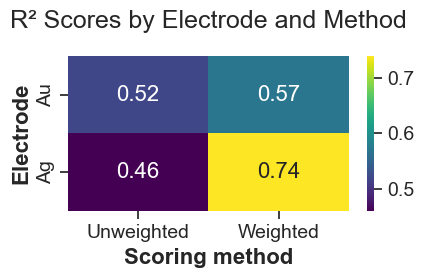

In [18]:
r2_data = {
    "Unweighted": {"Au": 0.52, "Ag": 0.46},
    "Weighted": {"Au": 0.57, "Ag": 0.74}
}

plot_r2_heatmap(r2_data)

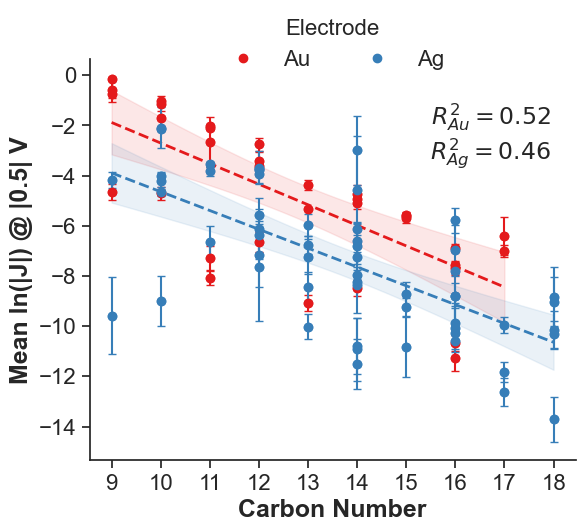

In [19]:
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score

regression_fits = {
    "Au": {"intercept": 5.5, "slope": -0.82},
    "Ag": {"intercept": 2.86, "slope": -0.75}
}

hue_order = substrate_data_clean_hierarch["electrode"].unique()
palette = sns.color_palette("Set1", n_colors=len(hue_order))
palette_dict = dict(zip(hue_order, palette))

g = sns.lmplot(
    data=substrate_data_clean_hierarch,
    x="carbon number",
    y="mean ln(|J|) @ |0.5| V",
    hue="electrode",
    fit_reg=False,
    aspect=1.2,
    palette=palette_dict,
    legend=False
)

g.set(xticks=list(range(9, 19)))
ax = g.ax
g.tick_params(labelsize=16)
g.set_xlabels("Carbon Number", fontsize=18)
g.set_ylabels("Mean ln(|J|) @ |0.5| V", fontsize=18)

r2_dict = {}

for hue_value in hue_order:
    color = palette_dict[hue_value]
    subset = substrate_data_clean_hierarch[
        substrate_data_clean_hierarch["electrode"] == hue_value
    ]

    x = subset["carbon number"].values
    y = subset["mean ln(|J|) @ |0.5| V"].values

    ax.errorbar(
        x,
        y,
        yerr=subset["SEM ln(|J|) @ |0.5| V"],
        fmt='o',
        ecolor=color,
        capsize=3,
        color=color
    )

    intercept = regression_fits[hue_value]["intercept"]
    slope = regression_fits[hue_value]["slope"]

    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color=color, linestyle='--', linewidth=2)

    # Compute R² using sklearn
    y_fit = intercept + slope * x
    r2 = r2_score(y, y_fit)
    r2_dict[hue_value] = r2

    # Confidence band
    n = len(x)
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    mean_x = np.mean(x)
    from scipy.stats import t
    t_val = t.ppf(0.975, df=n-2)
    conf = t_val * s_err * np.sqrt(1/n + (x_vals - mean_x)**2 / np.sum((x - mean_x)**2))

    ax.fill_between(x_vals, y_vals - conf, y_vals + conf, color=color, alpha=0.1)

# Custom legend
custom_handles = [
    Line2D([0], [0], marker='o', color=color, linestyle='', label=label)
    for label, color in palette_dict.items()
]

ax.legend(
    handles=custom_handles,
    title='Electrode',
    title_fontsize=16,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False,
    prop={'size': 16}
)

# Add textbox with R²
r2_text = "\n".join([f"$R^2_{{{key}}} = {value:.2f}$" for key, value in r2_dict.items()])

ax.text(
    0.95, 0.72, r2_text,
    transform=ax.transAxes,
    fontsize=17,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9)
)

plt.show()

Fitting based on the location:

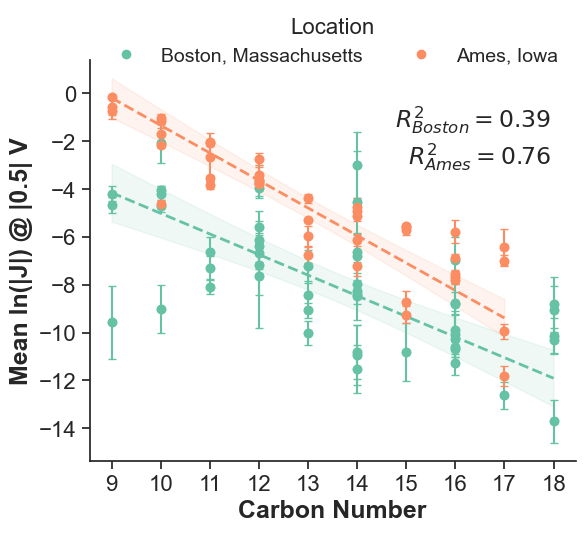

In [20]:
from scipy.stats import t

# Unique locations
hue_order = substrate_data_clean_hierarch["location"].unique()
palette = sns.color_palette("Set2", n_colors=len(hue_order))
palette_dict = dict(zip(hue_order, palette))

# Prepare the figure
g = sns.lmplot(
    data=substrate_data_clean_hierarch,
    x="carbon number",
    y="mean ln(|J|) @ |0.5| V",
    hue="location",
    fit_reg=False,
    aspect=1.2,
    palette=palette_dict,
    legend=False
)

g.set(xticks=list(range(9, 19)))
ax = g.ax
g.tick_params(labelsize=16)
g.set_xlabels("Carbon Number", fontsize=18)
g.set_ylabels("Mean ln(|J|) @ |0.5| V", fontsize=18)

r2_dict = {}
regression_fits = {}

# Fit linear regression for each location
for loc in hue_order:
    subset = substrate_data_clean_hierarch[substrate_data_clean_hierarch["location"] == loc]
    x = subset[["carbon number"]].values
    y = subset["mean ln(|J|) @ |0.5| V"].values

    # Optional: weight by inverse variance if available
    if "var ln(|J|) @ |0.5| V" in subset.columns:
        weights = 1 / subset["var ln(|J|) @ |0.5| V"].values
    else:
        weights = None

    # Fit linear regression
    model = LinearRegression()
    model.fit(x, y, sample_weight=weights)
    intercept, slope = model.intercept_, model.coef_[0]
    regression_fits[loc] = {"intercept": intercept, "slope": slope}

    # Compute predicted values
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color=palette_dict[loc], linestyle='--', linewidth=2)

    # Compute R²
    y_fit = model.predict(x)
    r2 = r2_score(y, y_fit)
    r2_dict[loc] = r2

    # Plot error bars
    ax.errorbar(
        subset["carbon number"],
        y,
        yerr=subset.get("SEM ln(|J|) @ |0.5| V", None),
        fmt='o',
        color=palette_dict[loc],
        ecolor=palette_dict[loc],
        capsize=3
    )

    # Confidence band
    n = len(x)
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    mean_x = np.mean(x)
    t_val = t.ppf(0.975, df=n-2)
    conf = t_val * s_err * np.sqrt(1/n + (x_vals - mean_x)**2 / np.sum((x - mean_x)**2))
    ax.fill_between(x_vals, y_vals - conf, y_vals + conf, color=palette_dict[loc], alpha=0.1)

# Custom legend
custom_handles = [
    Line2D([0], [0], marker='o', color=color, linestyle='', label=label)
    for label, color in palette_dict.items()
]
ax.legend(
    handles=custom_handles,
    title='Location',
    title_fontsize=16,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False,
    prop={'size': 14}
)

# Add textbox with R²
short_names = {
    "Boston, Massachusetts": "Boston",
    "Ames, Iowa": "Ames"
}

# Create R² text with short subscripts
r2_text = "\n".join([f"$R^2_{{{short_names.get(key, key)}}} = {value:.2f}$"
                      for key, value in r2_dict.items()])

ax.text(
    0.95, 0.72, r2_text,
    transform=ax.transAxes,
    fontsize=17,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9)
)

plt.show()

#### Weighted linear regression

In [21]:
for modeling_modality, heterosked in [("Unweighted", False), ("Weighted", True)]:
  print(f"\n\n{modeling_modality} scoring")

  for electrode, features, target, sample_weights in zip(["Au", "Ag"], [x_au_substrate, x_ag_substrate], [y_au_substrate, y_ag_substrate], [weights_ln1p_au_substrate, weights_ln1p_ag_substrate]):
    print(f"Electrode: {electrode}")

    fit_model(model=WeightedLinearRegression(), x=features, y=target, heterosked=heterosked, sample_weights=sample_weights)



Unweighted scoring
Electrode: Au
R²: 0.44
ln(J_0) = 7.77 A/cm^2,	beta=0.94 C^-1
Electrode: Ag
R²: 0.41
ln(J_0) = 6.00 A/cm^2,	beta=0.96 C^-1


Weighted scoring
Electrode: Au
R²: 0.78
ln(J_0) = 7.77 A/cm^2,	beta=0.94 C^-1
Electrode: Ag
R²: 0.66
ln(J_0) = 6.00 A/cm^2,	beta=0.96 C^-1


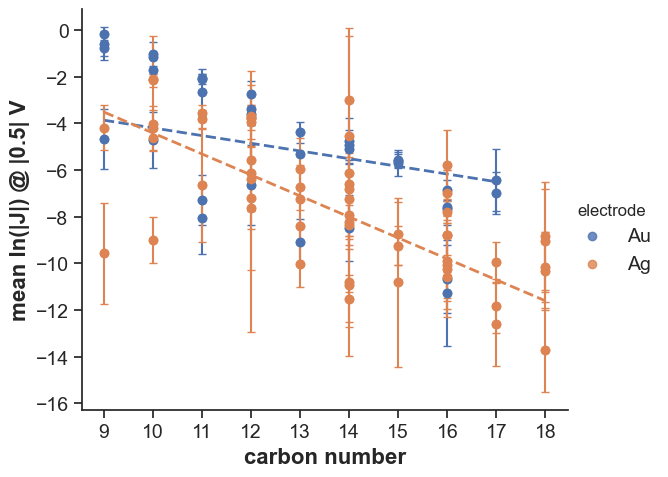

In [22]:
regression_fits = {
    "Au": {"intercept": -0.89, "slope": -0.33},
    "Ag": {"intercept": 4.59, "slope": -0.90}
}

# Create lmplot with hue
g = sns.lmplot(data=substrate_data_clean_hierarch, x="carbon number", y="mean ln(|J|) @ |0.5| V", hue="electrode", fit_reg=False, aspect=1.2)
g.set(xticks=list(range(9, 19)))

# Extract axes
ax = g.ax

# Add error bars using matplotlib for each hue category
hue_order = substrate_data_clean_hierarch["electrode"].unique()
palette = sns.color_palette(n_colors=len(hue_order))

for hue_value, color in zip(hue_order, palette):
    subset = substrate_data_clean_hierarch[substrate_data_clean_hierarch["electrode"] == hue_value]

    # Plot error bars for each subset
    ax.errorbar(subset["carbon number"], subset["mean ln(|J|) @ |0.5| V"], yerr=subset["std ln(|J|) @ |0.5| V"],
                fmt='o', ecolor=color, capsize=3, label=hue_value)

    # Get intercept and slope for the current category
    intercept = regression_fits[hue_value]['intercept']
    slope = regression_fits[hue_value]['slope']

    # Generate x values for plotting the regression line
    x_vals = np.linspace(subset["carbon number"].min(), subset["carbon number"].max(), 100)
    y_vals = intercept + slope * x_vals

    # Plot the regression line
    ax.plot(x_vals, y_vals, color=color, linestyle='--', linewidth=2, label=f'{hue_value} Linear Fit')

# Add legend
# ax.legend()

# Show the plot
plt.show()

### Grouped by carbon number

In [23]:
au_idx_physics = physics_data_clean.index[physics_data_clean["electrode"] == "Au"]
ag_idx_physics = physics_data_clean.index[physics_data_clean["electrode"] == "Ag"]

x_physics = physics_data_clean[["carbon number"]]
y_physics = physics_data_clean["mean ln(|J|) @ |0.5| V"]
weights_physics = 1 / physics_data_clean["var ln(|J|) @ |0.5| V"]

x_au_physics = x_physics.loc[au_idx_physics]
y_au_physics = y_physics.loc[au_idx_physics]
weights_au_physics = weights_physics.loc[au_idx_physics]

x_ag_physics = x_physics.loc[ag_idx_physics]
y_ag_physics = y_physics.loc[ag_idx_physics]
weights_ag_physics = weights_physics.loc[ag_idx_physics]

NameError: name 'physics_data_clean' is not defined

#### OLS

In [24]:
for modeling_modality, heterosked in [("Unweighted", False), ("Weighted", True)]:
  print(f"\n\n{modeling_modality} scoring")

  for electrode, features, target, sample_weights in zip(["Au", "Ag"], [x_au_physics, x_ag_physics], [y_au_physics, y_ag_physics], [weights_au_physics, weights_ag_physics]):
    print(f"Electrode: {electrode}")

    fit_model(model=LinearRegression(), x=features, y=target, heterosked=heterosked, sample_weights=sample_weights)



Unweighted scoring


NameError: name 'x_au_physics' is not defined

In [25]:
regression_fits = {
    "Au": {"intercept": 0.51, "slope": -0.52},
    "Ag": {"intercept": 3.51, "slope": -0.82}
}

# Create lmplot with hue
g = sns.lmplot(data=physics_data_clean, x="carbon number", y="mean ln(|J|) @ |0.5| V", hue="electrode", fit_reg=False, aspect=1.2)
g.set(xticks=list(range(9, 19)))

# Extract axes
ax = g.ax

# Add error bars using matplotlib for each hue category
hue_order = physics_data_clean["electrode"].unique()
palette = sns.color_palette(n_colors=len(hue_order))

for hue_value, color in zip(hue_order, palette):
    subset = physics_data_clean[physics_data_clean["electrode"] == hue_value]

    # Plot error bars for each subset
    ax.errorbar(subset["carbon number"], subset["mean ln(|J|) @ |0.5| V"], yerr=subset["std ln(|J|) @ |0.5| V"],
                fmt='o', ecolor=color, capsize=3, label=hue_value)

    # Get intercept and slope for the current category
    intercept = regression_fits[hue_value]['intercept']
    slope = regression_fits[hue_value]['slope']

    # Generate x values for plotting the regression line
    x_vals = np.linspace(subset["carbon number"].min(), subset["carbon number"].max(), 100)
    y_vals = intercept + slope * x_vals

    # Plot the regression line
    ax.plot(x_vals, y_vals, color=color, linestyle='--', linewidth=2, label=f'{hue_value} Linear Fit')

# Add legend
ax.legend()

# Show the plot
plt.show()

NameError: name 'physics_data_clean' is not defined

#### Weighted linear regression

In [26]:
for modeling_modality, heterosked in [("Unweighted", False), ("Weighted", True)]:
  print(f"\n\n{modeling_modality} scoring")

  for electrode, features, target, sample_weights in zip(["Au", "Ag"], [x_au_physics, x_ag_physics], [y_au_physics, y_ag_physics], [weights_au_physics, weights_ag_physics]):
    print(f"Electrode: {electrode}")

    fit_model(model=WeightedLinearRegression(), x=features, y=target, heterosked=heterosked, sample_weights=sample_weights)



Unweighted scoring


NameError: name 'x_au_physics' is not defined

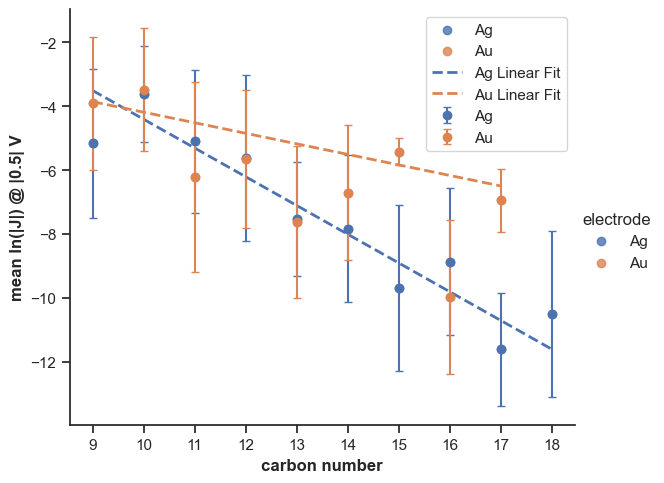

In [ ]:
regression_fits = {
    "Au": {"intercept": -0.89, "slope": -0.33},
    "Ag": {"intercept": 4.59, "slope": -0.90}
}

# Create lmplot with hue
g = sns.lmplot(data=physics_data_clean, x="carbon number", y="mean ln(|J|) @ |0.5| V", hue="electrode", fit_reg=False, aspect=1.2)
g.set(xticks=list(range(9, 19)))

# Extract axes
ax = g.ax

# Add error bars using matplotlib for each hue category
hue_order = physics_data_clean["electrode"].unique()
palette = sns.color_palette(n_colors=len(hue_order))

for hue_value, color in zip(hue_order, palette):
    subset = physics_data_clean[physics_data_clean["electrode"] == hue_value]

    # Plot error bars for each subset
    ax.errorbar(subset["carbon number"], subset["mean ln(|J|) @ |0.5| V"], yerr=subset["std ln(|J|) @ |0.5| V"],
                fmt='o', ecolor=color, capsize=3, label=hue_value)

    # Get intercept and slope for the current category
    intercept = regression_fits[hue_value]['intercept']
    slope = regression_fits[hue_value]['slope']

    # Generate x values for plotting the regression line
    x_vals = np.linspace(subset["carbon number"].min(), subset["carbon number"].max(), 100)
    y_vals = intercept + slope * x_vals

    # Plot the regression line
    ax.plot(x_vals, y_vals, color=color, linestyle='--', linewidth=2, label=f'{hue_value} Linear Fit')

# Add legend
ax.legend()

# Show the plot
plt.show()

## Prediction

In [ ]:
def calculate_overall_r2_score(y_true, y_pred, weights=None, draw_plot=False):
  # Calculate R^2 score
  r2 = r2_score(y_true=y_true, y_pred=y_pred, sample_weight=weights)

  print(f"R^2: {r2}")
  if draw_plot:
    plt.scatter(y_true, y_pred)
    plt.xlabel("True ln(J)")
    plt.ylabel("Predicted ln(J)")
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')
    plt.show()
  return r2

### Apply predictions to substrate-grouped data

In [ ]:
substrate_exp_decay_constants = {}
for electrode, features, target, sample_weights in zip(["Au", "Ag"], [x_au_substrate, x_ag_substrate], [y_au_substrate, y_ag_substrate], [weights_ln1p_au_substrate, weights_ln1p_ag_substrate]):
    print(f"Electrode: {electrode}")

    ln_J0, beta = fit_model(model=LinearRegression(), x=features, y=target, heterosked=True, sample_weights=sample_weights)
    substrate_exp_decay_constants[electrode] = {"ln(J0)": ln_J0, "beta": beta}

substrate_exp_decay_constants

Electrode: Au
R²: 0.67
ln(J_0) = 5.50 A/cm^2,	beta=0.82 C^-1
Electrode: Ag
R²: 0.61
ln(J_0) = 2.86 A/cm^2,	beta=0.75 C^-1


{'Au': {'ln(J0)': 5.4966049519341365, 'beta': 0.8232966237726476},
 'Ag': {'ln(J0)': 2.8579702057489262, 'beta': 0.753825689419355}}

In [ ]:
for dataset in [substrate_data_clean_hierarch]:
    dataset["predicted ln(|J|) @ |0.5| V"] = dataset["carbon number"].apply(lambda x: substrate_exp_decay_constants[dataset["electrode"][x]]["ln(J0)"] - substrate_exp_decay_constants[dataset["electrode"][x]]["beta"] * x)
    dataset["residual ln(|J|) @ |0.5| V"] = dataset["mean ln(|J|) @ |0.5| V"] - dataset["predicted ln(|J|) @ |0.5| V"]

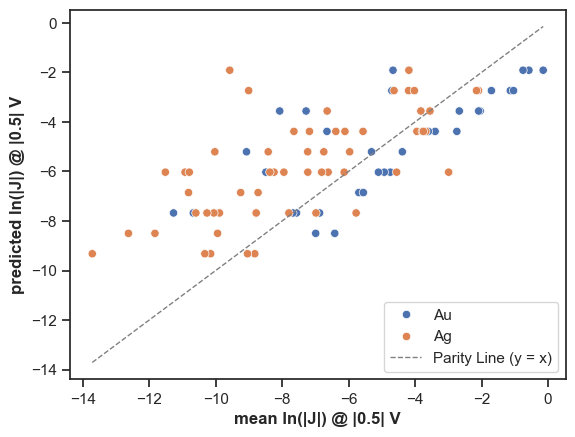

In [ ]:
sns.scatterplot(data=substrate_data_clean_hierarch, x="mean ln(|J|) @ |0.5| V", y="predicted ln(|J|) @ |0.5| V", hue="electrode")

# Add parity line (y = x)
x_min = substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"].min()
x_max = substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"].max()
plt.plot([x_min, x_max], [x_min, x_max], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')

# Optional: Add legend for the parity line
plt.legend()

# Show the plot
plt.show()

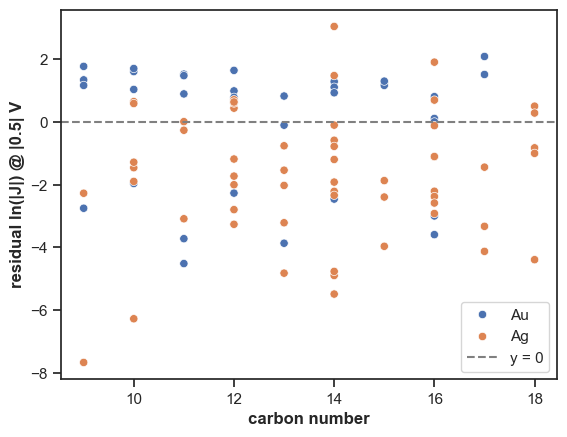

In [ ]:
sns.scatterplot(data=substrate_data_clean_hierarch, x="carbon number", y="residual ln(|J|) @ |0.5| V", hue="electrode")

# Add a horizontal line at y = 0
plt.axhline(y=0, color='grey', linestyle='--', linewidth=1.5, label='y = 0')

# Optional: Add legend to include the horizontal line label
plt.legend()

# Show the plot
plt.show()

In [ ]:
calculate_overall_r2_score(y_true=substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"],
                           y_pred=substrate_data_clean_hierarch["predicted ln(|J|) @ |0.5| V"],
                          #  weights = np.log1p(1 / substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]),
                           )

R^2: 0.371550304602248


0.371550304602248

In [ ]:
# # Create scatterplot and get the color mapping from Seaborn
# scatter = sns.scatterplot(
#     x=x,
#     y=y,
#     hue=substrate_data_clean_hierarch["electrode"],
#     palette="Set1",
#     s=50
# )

# # Get the colors assigned to each point
# hue_values = substrate_data_clean_hierarch["electrode"]
# palette = sns.color_palette("Set1", n_colors=hue_values.nunique())
# color_dict = dict(zip(hue_values.unique(), palette))

# # Plot error bars with matching colors
# for xi, yi, hue_val, xerr in zip(x, y, hue_values, substrate_data_clean_hierarch["SEM ln(|J|) @ |0.5| V"]):
#     plt.errorbar(
#         xi, yi,
#         xerr=xerr,
#         fmt='none',
#         elinewidth=2,
#         ecolor=color_dict[hue_val],
#         alpha=0.25
#     )

# # Parity line
# plt.plot(
#     [-15, 0],
#     [-15, 0],
#     color='#61a5c2',
#     linestyle='--',
#     linewidth=1
# )

# # Text
# plt.text(
#     0.65, 0.17,
#     r"$R^2_{{\mathrm{{unweighted}}}}$ = {:.2f}".format(0.37),
#     transform=plt.gca().transAxes,
#     fontsize=14,
#     verticalalignment='top',
#     alpha=0.8
# )

# # Axes labels and ticks
# plt.xlabel("True ln(|J|)", fontsize=16)
# plt.ylabel("Predicted ln(|J|)", fontsize=16)
# plt.xlim(-16, 0.5)
# plt.ylim(-16.5, 0.5)
# plt.xticks(np.arange(0, -17, -3))
# plt.yticks(np.arange(0, -17, -3))
# plt.tick_params(labelsize=14)
# plt.legend(title="Electrode")

location base fitting

In [ ]:
boston_idx_substrate = substrate_data_clean_hierarch.index[
    substrate_data_clean_hierarch["location"] == "Boston, Massachusetts"
]
ames_idx_substrate = substrate_data_clean_hierarch.index[
    substrate_data_clean_hierarch["location"] == "Ames, Iowa"
]

# Features and targets
x_substrate = substrate_data_clean_hierarch[["carbon number"]]
y_substrate = substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"]

# Sample weights
weights_substrate = 1 / substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]
weights_ln1p_substrate = np.log1p(weights_substrate)

# Split by location
x_boston_substrate = x_substrate.loc[boston_idx_substrate]
y_boston_substrate = y_substrate.loc[boston_idx_substrate]
weights_boston_substrate = weights_substrate.loc[boston_idx_substrate]
weights_ln1p_boston_substrate = weights_ln1p_substrate.loc[boston_idx_substrate]

x_ames_substrate = x_substrate.loc[ames_idx_substrate]
y_ames_substrate = y_substrate.loc[ames_idx_substrate]
weights_ames_substrate = weights_substrate.loc[ames_idx_substrate]
weights_ln1p_ames_substrate = weights_ln1p_substrate.loc[ames_idx_substrate]

In [ ]:
# Dictionary to store decay constants per location
substrate_exp_decay_constants_location = {}

for location, features, target, sample_weights in zip(
    ["Boston, Massachusetts", "Ames, Iowa"],
    [x_boston_substrate, x_ames_substrate],
    [y_boston_substrate, y_ames_substrate],
    [weights_ln1p_boston_substrate, weights_ln1p_ames_substrate]
):
    print(f"Location: {location}")

    ln_J0, beta = fit_model(
        model=LinearRegression(),
        x=features,
        y=target,
        heterosked=True,
        sample_weights=sample_weights
    )
    substrate_exp_decay_constants_location[location] = {"ln(J0)": ln_J0, "beta": beta}

substrate_exp_decay_constants_location

In [ ]:
for dataset in [substrate_data_clean_hierarch]:
    # Predict using location-specific decay constants
    dataset["predicted ln(|J|) @ |0.5| V (location)"] = dataset.apply(
        lambda row: substrate_exp_decay_constants_location[row["location"]]["ln(J0)"]
                    - substrate_exp_decay_constants_location[row["location"]]["beta"] * row["carbon number"],
        axis=1
    )

    # Residuals
    dataset["residual ln(|J|) @ |0.5| V (location)"] = (
        dataset["mean ln(|J|) @ |0.5| V"] - dataset["predicted ln(|J|) @ |0.5| V (location)"]
    )

In [ ]:
calculate_overall_r2_score(y_true=substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"],
                           y_pred=substrate_data_clean_hierarch["predicted ln(|J|) @ |0.5| V (location)"],
                          #  weights = np.log1p(1 / substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]),
                           )

In [ ]:
# Use the location-based predicted column
x = substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"]
y = substrate_data_clean_hierarch["predicted ln(|J|) @ |0.5| V (location)"]

# Scatterplot colored by location
scatter = sns.scatterplot(
    x=x,
    y=y,
    hue=substrate_data_clean_hierarch["location"],
    palette="Set2",
    s=50
)

# Get the colors assigned to each point
hue_values = substrate_data_clean_hierarch["location"]
palette = sns.color_palette("Set2", n_colors=hue_values.nunique())
color_dict = dict(zip(hue_values.unique(), palette))

# Plot error bars with matching colors
for xi, yi, hue_val, xerr in zip(
    x, y, hue_values, substrate_data_clean_hierarch["SEM ln(|J|) @ |0.5| V"]
):
    plt.errorbar(
        xi, yi,
        xerr=xerr,
        fmt='none',
        elinewidth=2,
        ecolor=color_dict[hue_val],
        alpha=0.25
    )

# Parity line
plt.plot(
    [-15, 0],
    [-15, 0],
    color='#61a5c2',
    linestyle='--',
    linewidth=1
)

# Text: update R^2 if recalculated
plt.text(
    0.65, 0.17,
    r"$R^2_{{\mathrm{{unweighted}}}}$ = {:.2f}".format(0.70),  # replace with actual score
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top',
    alpha=0.8
)

# Axes labels and ticks
plt.xlabel("True ln(|J|)", fontsize=16)
plt.ylabel("Predicted ln(|J|)", fontsize=16)
plt.xlim(-16, 0.5)
plt.ylim(-16.5, 0.5)
plt.xticks(np.arange(0, -17, -3))
plt.yticks(np.arange(0, -17, -3))
plt.tick_params(labelsize=14)
plt.legend(title="Location")

In [ ]:
x = substrate_data_clean_hierarch["mean ln(|J|) @ |0.5| V"]
y = substrate_data_clean_hierarch["residual ln(|J|) @ |0.5| V (location)"]

# Scatterplot colored by location
scatter = sns.scatterplot(
    x=x,
    y=y,
    hue=substrate_data_clean_hierarch["location"],
    palette="Set2",
    s=55
)

# Get the colors assigned to each point
hue_values = substrate_data_clean_hierarch["location"]
palette = sns.color_palette("Set2", n_colors=hue_values.nunique())
color_dict = dict(zip(hue_values.unique(), palette))


# Zero residual reference line
plt.axhline(y=0, color='grey', linestyle='--', linewidth=2, label='y = 0')

# Axes labels and ticks
plt.xlabel("True ln(|J|)", fontsize=16.5)
plt.ylabel("Residual ln(|J|)", fontsize=16.5)
plt.xlim(-16, 0.5)
plt.xticks(np.arange(0, -17, -3))
plt.tick_params(labelsize=14.5)
plt.legend(title="Location")

In [ ]:
draw_heat_pair_plot(df=substrate_data_clean_hierarch, parameters=pairwise_selected_features, title="Pairwise correlations, grouped by substrate (hierarchical aggregation)", hex_bin=True)

In [ ]:
x = substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]
y = 1/x
plt.scatter(x, y)
# plt.plot([min(x), max(x)], [min(x), max(x)], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Hierarchically aggregated variance ($\sigma^2$)")
plt.ylabel("1 / $\sigma^2$")
print(min(y), max(y))

In [ ]:
x = substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]
y = np.log1p(1/x)
plt.scatter(x, y)
# plt.plot([min(x), max(x)], [min(x), max(x)], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Hierarchically aggregated variance ($\sigma^2$)")
plt.ylabel("ln(1 + 1 / $\sigma^2$)")
print(min(y), max(y))

In [ ]:
x = substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]
y = np.sqrt(1/x)
plt.scatter(x, y)
# plt.plot([min(x), max(x)], [min(x), max(x)], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Hierarchically aggregated variance ($\sigma^2$)")
plt.ylabel("$\sqrt{1 / \sigma^2}$")
print(min(y), max(y))

In [ ]:
x = substrate_data_clean_hierarch["var ln(|J|) @ |0.5| V"]
y1 = 1/x
y2 = np.log1p(1/x)
y3 = np.sqrt(1/x)

def get_range_for_legend(y):
  return [f"{val:.2g}" for val in [min(y), max(y)]]

range_y1 = get_range_for_legend(y1)
range_y2 = get_range_for_legend(y2)
range_y3 = get_range_for_legend(y3)

plt.scatter(x, y1, label=f"$1 / \sigma^2$ [{range_y1[0]}, {range_y1[1]}]")
plt.scatter(x, y2, label=f"$ln(1 + 1 / \sigma^2$) [{range_y2[0]}, {range_y2[1]}]")
plt.scatter(x, y3, label=f"$sqrt(1 / \sigma^2)$ [{range_y3[0]}, {range_y3[1]}]")
# plt.plot([min(x), max(x)], [min(x), max(x)], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Hierarchically aggregated variance ($\sigma^2$)")
plt.ylabel("Weights")
plt.legend()
# print(min(y), max(y))

### Apply group wise fitting for generalisability

In [ ]:
carbon = dataset["carbon number"].values

low_mask = (carbon <= 11).astype(int)     # 1 = low, 0 = rest
high_mask = ((carbon >= 15) & (carbon <= 17)).astype(int)   # 1 = high, 0 = rest


In [ ]:
substrate_exp_decay_constants = {}

for electrode, features, target, sample_weights in zip(
    ["Au", "Ag"],
    [x_au_substrate, x_ag_substrate],
    [y_au_substrate, y_ag_substrate],
    [weights_ln1p_au_substrate, weights_ln1p_ag_substrate]
):
    substrate_exp_decay_constants[electrode] = {"low": {}, "high": {}}

    carbon = features["carbon number"].values

    low_mask = (carbon <= 11)            # True/False
    high_mask = (15 <= carbon) & (carbon <= 17)

    # LOW GROUP MODELS
    # low=1
    lnJ0_l1, beta_l1 = fit_model(
        model=LinearRegression(),
        x=features[low_mask],
        y=target[low_mask],
        heterosked=True,
        sample_weights=sample_weights[low_mask]
    )
    # low=0
    lnJ0_l0, beta_l0 = fit_model(
        model=LinearRegression(),
        x=features[~low_mask],
        y=target[~low_mask],
        heterosked=True,
        sample_weights=sample_weights[~low_mask]
    )

    substrate_exp_decay_constants[electrode]["low"][1] = {"ln(J0)": lnJ0_l1, "beta": beta_l1}
    substrate_exp_decay_constants[electrode]["low"][0] = {"ln(J0)": lnJ0_l0, "beta": beta_l0}

    # HIGH GROUP MODELS
    # high=1
    lnJ0_h1, beta_h1 = fit_model(
        model=LinearRegression(),
        x=features[high_mask],
        y=target[high_mask],
        heterosked=True,
        sample_weights=sample_weights[high_mask]
    )
    # high=0
    lnJ0_h0, beta_h0 = fit_model(
        model=LinearRegression(),
        x=features[~high_mask],
        y=target[~high_mask],
        heterosked=True,
        sample_weights=sample_weights[~high_mask]
    )

    substrate_exp_decay_constants[electrode]["high"][1] = {"ln(J0)": lnJ0_h1, "beta": beta_h1}
    substrate_exp_decay_constants[electrode]["high"][0] = {"ln(J0)": lnJ0_h0, "beta": beta_h0}


In [ ]:
substrate_exp_decay_constants

In [ ]:
for dataset in [substrate_data_clean_hierarch]:

    def predict_low(row):
        carbon = row["carbon number"]
        electrode = row["electrode"]
        group = 1 if carbon <= 11 else 0
        params = substrate_exp_decay_constants[electrode]["low"][group]
        return params["ln(J0)"] - params["beta"] * carbon

    def predict_high(row):
        carbon = row["carbon number"]
        electrode = row["electrode"]
        group = 1 if (15 <= carbon <= 17) else 0
        params = substrate_exp_decay_constants[electrode]["high"][group]
        return params["ln(J0)"] - params["beta"] * carbon

    dataset["predicted ln(|J|) @ |0.5| V (low-group)"] = dataset.apply(predict_low, axis=1)
    dataset["predicted ln(|J|) @ |0.5| V (high-group)"] = dataset.apply(predict_high, axis=1)

    dataset["residual ln(|J|) @ |0.5| V (low-group)"] = \
        dataset["mean ln(|J|) @ |0.5| V"] - dataset["predicted ln(|J|) @ |0.5| V (low-group)"]

    dataset["residual ln(|J|) @ |0.5| V (high-group)"] = \
        dataset["mean ln(|J|) @ |0.5| V"] - dataset["predicted ln(|J|) @ |0.5| V (high-group)"]


In [ ]:
substrate_data_clean_hierarch.columns.to_list()

In [ ]:
def plot_parity_with_r2(
        dataset,
        group_label="",
        ax=None
    ):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    x = dataset["mean ln(|J|) @ |0.5| V"]
    y = dataset[f"predicted ln(|J|) @ |0.5| V{group_label}"]

    weights = np.log1p(1 / dataset["var ln(|J|) @ |0.5| V"])
    r2_weighted = calculate_overall_r2_score(
        y_true=x,
        y_pred=y,
        weights=weights,
    )

    ax.errorbar(
        x,
        y,
        xerr=dataset["std ln(|J|) @ |0.5| V"],
        fmt="o",
        elinewidth=2,
        ecolor='#1f77b430',
        color="#013a63"
    )

    ax.plot(
        [x.min(), x.max()],
        [x.min(), x.max()],
        color='#61a5c2',
        linestyle='--',
        linewidth=1,
        label="Parity Line (y = x)"
    )

    ax.text(
        0.65, 0.17,
        rf"$R^2_{{\mathrm{{weighted}}}}$ = {r2_weighted:.2f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        alpha=0.8
    )

    ax.set_xlabel("True ln(|J|)")
    ax.set_ylabel(f"Predicted ln(|J|) {group_label}")
    plt.show()

In [ ]:
plot_parity_with_r2(
    dataset=substrate_data_clean_hierarch,
    group_label=" (high-group)"
)


In [ ]:
plot_parity_with_r2(
    dataset=substrate_data_clean_hierarch,
    group_label=" (low-group)"
)

In [ ]:
plot_parity_with_r2(
    dataset=substrate_data_clean_hierarch,
    group_label=""
)

### Apply predictions to scan data, then group by substrate

In [ ]:
carbon_exp_decay_constants = {}
for electrode, features, target in zip(["Au", "Ag"], [x_au_physics, x_ag_physics], [y_au_physics, y_ag_physics]):
    print(f"Electrode: {electrode}")

    ln_J0, beta = fit_model(model=LinearRegression(), x=features, y=target, heterosked=False)
    carbon_exp_decay_constants[electrode] = {"ln(J0)": ln_J0, "beta": beta}

carbon_exp_decay_constants

#### Apply predictions

In [ ]:
scan_data_resids = scan_data_clean.copy()
for dataset in [scan_data_resids]:
    dataset["predicted ln(|J|) @ |0.5| V"] = dataset["carbon number"].apply(lambda x: carbon_exp_decay_constants[dataset["electrode"][x]]["ln(J0)"] - carbon_exp_decay_constants[dataset["electrode"][x]]["beta"] * x)
    dataset["residual ln(|J|) @ |0.5| V"] = dataset["scan mean ln(|J|) @ |0.5| V"] - dataset["predicted ln(|J|) @ |0.5| V"]

In [ ]:
sns.scatterplot(data=scan_data_resids, x="scan mean ln(|J|) @ |0.5| V", y="predicted ln(|J|) @ |0.5| V", hue="electrode")

# Add parity line (y = x)
x_min = scan_data_resids["scan mean ln(|J|) @ |0.5| V"].min()
x_max = scan_data_resids["scan mean ln(|J|) @ |0.5| V"].max()
plt.plot([x_min, x_max], [x_min, x_max], color='grey', linestyle='--', linewidth=1, label='Parity Line (y = x)')

# Optional: Add legend for the parity line
plt.legend()

# Show the plot
plt.show()

In [ ]:
sns.scatterplot(data=scan_data_resids, x="carbon number", y="residual ln(|J|) @ |0.5| V", hue="electrode")

# Add a horizontal line at y = 0
plt.axhline(y=0, color='grey', linestyle='--', linewidth=1.5, label='y = 0')

# Optional: Add legend to include the horizontal line label
plt.legend()

# Show the plot
plt.show()

In [ ]:
calculate_overall_r2_score(y_true=scan_data_resids["scan mean ln(|J|) @ |0.5| V"], y_pred=scan_data_resids["predicted ln(|J|) @ |0.5| V"])

#### Group by substrate

In [ ]:
def calculate_scan_residual_statistics(df, grouping_columns):
  stats_df = df.groupby([*grouping_columns, 'location', 'carbon number', 'electrode', 'scan V direction']).agg(
      **{

        **{f"{stat_name} {scale_name} residual @ {v_name} V": (f"residual {scale_name} @ {v_name} V", stats_funcs[stat_name]) for v_name, stat_name, scale_name in product(["|0.5|"], stats_funcs.keys(), ["ln(|J|)"])
        },

        # # Predicted current densities
        # "predicted ln(|J|) @ |0.5| V": ("predicted ln(|J|) @ |0.5| V", "mean"),
        # "predicted std ln(|J|) @ |0.5| V": ("predicted ln(|J|) @ |0.5| V", stats_funcs["std"]),  # Simple sanity check. Std dev should be 0.

        # True mean of the substrate
        "true mean ln(|J|) @ |0.5| V": ("scan mean ln(|J|) @ |0.5| V", "mean"),
        "true std ln(|J|) @ |0.5| V": ("scan mean ln(|J|) @ |0.5| V", stats_funcs["std"]),

        # More stats features
        "sample size": ("scan ID", "size"),

        # Other feature means
        'temperature': ('temperature', 'mean'),
        'humidity': ('humidity', 'mean'),
        'datetime': ('datetime', 'mean'),
        'dew point': ('dew point', 'mean'),
        'sea level air pressure': ('sea level air pressure', 'mean'),
        'one hour precipitation':('one hour precipitation', 'mean'),
        'water content':('water content from dew', 'mean'),

    }
  ).reset_index()
  return stats_df

def generate_grouped_scan_residuals(df, grouping_columns, additional_log_columns: list[str]=["water content"]):
  # Generate grouped data
  stats_df = calculate_scan_residual_statistics(df, grouping_columns)

  # Generate time-based data
  stats_df = extract_from_datetime(stats_df)
  stats_df = calculate_cyclic_feature(stats_df, 'time of day', 'day of week','day of year')

  # Calculate log of simple stats for convenience
  for column in additional_log_columns:
    stats_df[f"log_{column}"] = np.log10(stats_df[column])

  return stats_df

In [ ]:
substrate_data_scan_resids = generate_grouped_scan_residuals(scan_data_resids,['substrate ID'])

for dataset in [substrate_data_scan_resids]:
    dataset["predicted ln(|J|) @ |0.5| V"] = dataset["carbon number"].apply(lambda x: carbon_exp_decay_constants[dataset["electrode"][x]]["ln(J0)"] - carbon_exp_decay_constants[dataset["electrode"][x]]["beta"] * x)

In [ ]:
distribution_plot(df=substrate_data_scan_resids, parameters=features_to_show, columns_per_row=3,
                  log_cutoff=1e7, figsize=(16,9),title = "Feature value distributions after taking average on substrate ID (for residuals)")

In [ ]:
plot_value_counts(substrate_data_scan_resids, "electrode", title="Count of Each Electrode Type grouped by substrate")
plot_value_counts(substrate_data_scan_resids, "location", title="Count of Each location Type grouped by substrate")

In [ ]:
residual_statistical_parameters = [f"{var} ln(|J|) residual @ |0.5| V" for var in ["mean", "median", "std", "var", "skew", "kurtosis", "K-S test", "S-W test"]]
residual_statistical_parameters.extend(["true mean ln(|J|) @ |0.5| V", "true std ln(|J|) @ |0.5| V", "predicted ln(|J|) @ |0.5| V"])
residual_statistical_parameters.append("sample size")

distribution_plot(df=substrate_data_scan_resids, parameters=residual_statistical_parameters, columns_per_row=4,
                  log_cutoff=10, figsize=(18,12),title = "Statistical parameter value distributions after taking average on substrate ID (for residuals)")

In [ ]:
calculate_overall_r2_score(y_true=substrate_data_scan_resids["true mean ln(|J|) @ |0.5| V"], y_pred=substrate_data_scan_resids["predicted ln(|J|) @ |0.5| V"])

# Saving data

**Including shorts**

In [ ]:
substrate_data.to_csv(data_folder/'substrate_averaged_data.csv',index=False)

**Exlcuding shorts & incorrect scan direction**

In [ ]:
substrate_data_clean.to_csv(data_folder/'substrate_averaged_clean_data.csv',index=False)

**Hierarchically aggregated, excluding shorts & incorrect scan direction**

In [ ]:
substrate_data_clean_hierarch.to_csv(data_folder / "substrate_hierarchically_averaged_clean_data.csv", index=False)

**Scan residuals dataset**

In [ ]:
substrate_data_scan_resids.to_csv(data_folder / "substrate_averaged_residuals.csv", index=False)